In [12]:
# ── Cell 1: Install all packages ──────────────────────────────────────────────
# Removes triton conflict and pins known-good versions for Kaggle T4

!pip uninstall -y bitsandbytes triton 2>/dev/null
!pip install -q \
    bitsandbytes==0.45.3 \
    transformers==4.46.3 \
    accelerate==0.34.2 \
    peft==0.13.2 \
    trl==0.11.4 \
    gradio

import torch, bitsandbytes, transformers, peft
print(f"transformers : {transformers.__version__}")
print(f"bitsandbytes : {bitsandbytes.__version__}")
print(f"peft         : {peft.__version__}")
print(f"CUDA         : {torch.cuda.is_available()}  |  GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print("✅ All packages ready")

Found existing installation: triton 3.6.0
Uninstalling triton-3.6.0:
  Successfully uninstalled triton-3.6.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 25.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 93.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.6/316.6 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 78.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 9.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 13.0 MB/s eta 0:00:00


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

2026-05-09 17:20:30.561748: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778347231.191409      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778347231.322140      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778347232.266960      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778347232.267001      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778347232.267003      57 computation_placer.cc:177] computation placer alr

transformers : 4.46.3
bitsandbytes : 0.45.3
peft         : 0.13.2
CUDA         : True  |  GPU: Tesla T4
✅ All packages ready


In [7]:
# ── Cell 2: HuggingFace Login ─────────────────────────────────────────────────
# Requires HF_TOKEN secret in Kaggle Settings → Secrets → Add New Secret

from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

hf_token = UserSecretsClient().get_secret("HF_TOKEN")
login(token=hf_token)
print("✅ Logged in to HuggingFace")

✅ Logged in to HuggingFace


In [8]:
# ── Cell 3: Setup project files ───────────────────────────────────────────────
import os, shutil, sys

# ── Paths (update INPUT_BASE if your Kaggle username/dataset name is different) ─
INPUT_BASE   = "/kaggle/input/datasets/saifmamdouh11/opinion-mining-project"
PROJECT_PATH = f"{INPUT_BASE}/opinion_mining_project_v2/opinion_mining_project"
WORKING_DIR  = "/kaggle/working/opinion_mining_project"

print(f"📂 Looking for project at: {PROJECT_PATH}")

if not os.path.exists(PROJECT_PATH):
    # Fallback: scan /kaggle/input for the project folder
    print("⚠️  Path not found — scanning /kaggle/input for project files...")
    for root, dirs, files in os.walk("/kaggle/input"):
        if "config.py" in files and "train.py" in files:
            PROJECT_PATH = root
            print(f"💡 Found project at: {PROJECT_PATH}")
            break
    else:
        raise FileNotFoundError(
            "Could not find opinion_mining_project. "
            "Make sure you attached the dataset to this notebook."
        )

# Copy project files to /kaggle/working so we can write outputs there
if not os.path.exists(WORKING_DIR):
    shutil.copytree(PROJECT_PATH, WORKING_DIR)
    print(f"✅ Copied project → {WORKING_DIR}")
else:
    print(f"✅ Project already in {WORKING_DIR}")

# Fix double-nested folder if zip extracted with an extra level
nested = os.path.join(WORKING_DIR, "opinion_mining_project")
if os.path.exists(nested):
    print("🔧 Fixing double-nested folder...")
    for item in os.listdir(nested):
        src  = os.path.join(nested, item)
        dest = os.path.join(WORKING_DIR, item)
        if not os.path.exists(dest):
            shutil.move(src, dest)
    shutil.rmtree(nested, ignore_errors=True)
    print("✅ Fixed.")

os.chdir(WORKING_DIR)
sys.path.insert(0, WORKING_DIR)
print(f"\n📍 Working directory: {os.getcwd()}")
print(f"📦 Contents: {os.listdir('.')}")

📂 Looking for project at: /kaggle/input/datasets/saifmamdouh11/opinion-mining-project/opinion_mining_project_v2/opinion_mining_project
✅ Project already in /kaggle/working/opinion_mining_project

📍 Working directory: /kaggle/working/opinion_mining_project
📦 Contents: ['requirements.txt', 'config.py', 'evaluate.py', 'data', 'outputs', '.gitignore', 'train.py', '__pycache__', 'notebooks', 'inference.py', 'README.md']


In [9]:
# ── Cell 4: Prepare Dataset ───────────────────────────────────────────────────
# Parses SemEval-2014 XML files if present, otherwise generates synthetic demo data
# Output: data/processed/train.jsonl, val.jsonl, test.jsonl

!python data/prepare_dataset.py

import json
with open("data/processed/dataset_stats.json") as f:
    stats = json.load(f)
print("\nDataset stats:")
print(json.dumps(stats, indent=2))

  Parsed 1488 sentences from Laptops_Train_v2.xml
  Parsed  422 sentences from Laptops_Test_Gold.xml
  Parsed 2021 sentences from Restaurants_Train_v2.xml
  Parsed  606 sentences from Restaurants_Test_Gold.xml

  Total records: 4,537
  Wrote 3,629 records → /kaggle/working/opinion_mining_project/data/processed/train.jsonl
  Wrote 453 records → /kaggle/working/opinion_mining_project/data/processed/val.jsonl
  Wrote 455 records → /kaggle/working/opinion_mining_project/data/processed/test.jsonl

  Stats → /kaggle/working/opinion_mining_project/data/processed/dataset_stats.json
{
  "total_sentences": 4537,
  "total_aspects": 7839,
  "split_sizes": {
    "train": 3629,
    "val": 453,
    "test": 455
  },
  "sentiment_distribution": {
    "positive": 4220,
    "negative": 1995,
    "neutral": 1458,
    "conflict": 166
  },
  "domain_distribution": {
    "restaurant": 2627,
    "laptop": 1910
  },
  "avg_aspects_per_sentence": 1.73
}

Dataset stats:
{
  "total_sentences": 4537,
  "total_aspe

In [13]:
# ── Cell 5: Fine-Tune (QLoRA) ─────────────────────────────────────────────────
# Skip this cell if final_adapter/ already exists from a previous run

import os

if os.path.exists("./final_adapter/adapter_config.json"):
    print("✅ Adapter already exists at ./final_adapter/")
    print("   Skipping training. Run Cell 6 to evaluate.")
else:
    print("🚀 Starting training... (2–3 hours on T4)")
    !python train.py
    print("\n✅ Training complete!")
    print("Adapter saved at:", os.path.abspath("./final_adapter"))

🚀 Starting training... (2–3 hours on T4)
^C
Traceback (most recent call last):
  File "/kaggle/working/opinion_mining_project/train.py", line 15, in <module>
    from datasets import Dataset, DatasetDict
  File "/usr/local/lib/python3.12/dist-packages/datasets/__init__.py", line 17, in <module>
    from .arrow_dataset import Column, Dataset
  File "/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py", line 80, in <module>
    from .arrow_writer import ArrowWriter, OptimizedTypedSequence
  File "/usr/local/lib/python3.12/dist-packages/datasets/arrow_writer.py", line 30, in <module>
    from .features import Audio, Features, Image, Pdf, Value, Video
  File "/usr/local/lib/python3.12/dist-packages/datasets/features/__init__.py", line 22, in <module>
    from .features import Array2D, Array3D, Array4D, Array5D, ClassLabel, Features, Json, LargeList, List, Sequence, Value
  File "/usr/local/lib/python3.12/dist-packages/datasets/features/features.py", line 46, in <module>
    f

In [14]:
# ── Cell 6: Find and Verify Adapter ──────────────────────────────────────────
# Auto-detects the adapter whether it was just trained or uploaded as a dataset

import os, json

# Priority order: local training output → uploaded dataset
ADAPTER_CANDIDATES = [
    "./final_adapter",                              # trained this session
    "/kaggle/working/opinion_mining_project/final_adapter",
    "/kaggle/input/datasets/saifmamdouh11/opinion-mining-project",                            # uploaded to Kaggle dataset
]

ADAPTER_PATH = None
for candidate in ADAPTER_CANDIDATES:
    cfg = os.path.join(candidate, "adapter_config.json")
    if os.path.exists(cfg):
        ADAPTER_PATH = candidate
        print(f"✅ Adapter found at: {ADAPTER_PATH}")
        break

if ADAPTER_PATH is None:
    raise FileNotFoundError(
        "No adapter found! Either:\n"
        "  1. Run Cell 5 to train the model, OR\n"
        f"  2. Upload final_adapter/ files to your Kaggle dataset at:\n"
        f"     {ADAPTER_CANDIDATES[-1]}"
    )

# Show adapter files
print("\n📁 Adapter files:")
for f in os.listdir(ADAPTER_PATH):
    size = os.path.getsize(os.path.join(ADAPTER_PATH, f))
    print(f"   {f:<40} {size/1024:.1f} KB")

# Show training summary if available
summary_path = os.path.join(ADAPTER_PATH, "training_summary.json")
if os.path.exists(summary_path):
    with open(summary_path) as f:
        summary = json.load(f)
    print("\n📊 Training Summary:")
    print(json.dumps(summary, indent=2))

✅ Adapter found at: /kaggle/input/datasets/saifmamdouh11/opinion-mining-project

📁 Adapter files:
   adapter_model.safetensors                95026.9 KB
   opinion_mining_project_v2                0.0 KB
   training_summary.json                    0.2 KB
   adapter_config.json                      0.7 KB

📊 Training Summary:
{
  "model": "meta-llama/Llama-3.2-3B-Instruct",
  "lora_r": 16,
  "lora_alpha": 32,
  "epochs": 3,
  "total_steps": 678,
  "final_train_loss": 0.0505,
  "final_eval_loss": 0.0506,
  "adapter_path": "./final_adapter"
}


In [15]:
# ── Cell 7: Evaluate Both Models ─────────────────────────────────────────────
# Runs base model (zero-shot) AND fine-tuned model on test set
# Saves comparison plots to outputs/evaluation/
# Takes ~30 minutes on T4  |  ⚡ SKIPPED automatically if results already exist

import os, sys, shutil

# ── Auto-setup: make sure working dir exists (safe to re-run) ─────────────────
WORKING_DIR  = "/kaggle/working/opinion_mining_project"
INPUT_BASE   = "/kaggle/input/datasets/saifmamdouh11/opinion-mining-project"
PROJECT_PATH = f"{INPUT_BASE}/opinion_mining_project_v2/opinion_mining_project"

if not os.path.exists(WORKING_DIR):
    print("⚠️  Working dir not found — running setup...")
    # Fallback scan if default path is wrong
    if not os.path.exists(PROJECT_PATH):
        for root, dirs, files in os.walk("/kaggle/input"):
            if "config.py" in files and "train.py" in files:
                PROJECT_PATH = root
                print(f"💡 Found project at: {PROJECT_PATH}")
                break
    shutil.copytree(PROJECT_PATH, WORKING_DIR)
    print(f"✅ Project copied → {WORKING_DIR}")
    # Fix double-nested folder
    nested = os.path.join(WORKING_DIR, "opinion_mining_project")
    if os.path.exists(nested):
        for item in os.listdir(nested):
            src, dest = os.path.join(nested, item), os.path.join(WORKING_DIR, item)
            if not os.path.exists(dest):
                shutil.move(src, dest)
        shutil.rmtree(nested, ignore_errors=True)

os.chdir(WORKING_DIR)
sys.path.insert(0, WORKING_DIR)
print(f"📍 Working dir: {WORKING_DIR}")

# ── Auto-detect adapter ────────────────────────────────────────────────────────
ADAPTER_CANDIDATES = [
    os.path.join(WORKING_DIR, "final_adapter"),
    INPUT_BASE,
]
try:
    ADAPTER_PATH  # already set by Cell 6
except NameError:
    ADAPTER_PATH = None
    for c in ADAPTER_CANDIDATES:
        if os.path.exists(os.path.join(c, "adapter_config.json")):
            ADAPTER_PATH = c
            print(f"✅ Adapter auto-detected: {ADAPTER_PATH}")
            break
    if ADAPTER_PATH is None:
        raise FileNotFoundError(
            "No adapter found! Run Cell 5 to train, or upload final_adapter/ to your dataset."
        )

# ── Skip if results already exist ─────────────────────────────────────────────
METRICS_PATH = "outputs/evaluation/metrics.json"
FORCE_EVAL   = False   # ← set True to re-run evaluation even if results exist

if not FORCE_EVAL and os.path.exists(METRICS_PATH):
    print("✅ Evaluation results already exist:", os.path.abspath(METRICS_PATH))
    print("   Skipping. Run Cell 7b to view metrics.")
    print("   (Set FORCE_EVAL = True above to re-run)")
else:
    print("🚀 Starting evaluation... (~30 min on T4)")
    !python evaluate.py \
        --adapter_path {ADAPTER_PATH} \
        --compare
    print("\n✅ Evaluation complete!")


📍 Working dir: /kaggle/working/opinion_mining_project
🚀 Starting evaluation... (~30 min on T4)
2026-05-09 17:21:28.590874: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778347288.614629     185 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778347288.622445     185 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778347288.641425     185 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778347288.641450     185 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more tha

In [16]:
# ── Cell 7b: Print Metrics Table ─────────────────────────────────────────────

import json

with open("outputs/evaluation/metrics.json") as f:
    metrics = json.load(f)

base = metrics.get("base", {})
lora = metrics.get("lora", {})

print(f"{'Metric':<22} {'Base':>8} {'LoRA':>8} {'Δ':>8}")
print("-" * 50)
for key, label in [
    ("accuracy",      "Accuracy"),
    ("f1_macro",      "F1 Macro"),
    ("json_validity", "JSON Validity"),
]:
    b = base.get(key, 0)
    l = lora.get(key, 0)
    print(f"{label:<22} {b:>8.4f} {l:>8.4f} {l-b:>+8.4f}")

print("\nPer-class F1:")
print(f"{'Sentiment':<15} {'Base':>8} {'LoRA':>8}")
print("-" * 33)
for s in ["positive", "negative", "neutral", "conflict"]:
    b = base.get("per_class_f1", {}).get(s, 0)
    l = lora.get("per_class_f1", {}).get(s, 0)
    print(f"{s:<15} {b:>8.4f} {l:>8.4f}")

Metric                     Base     LoRA        Δ
--------------------------------------------------
Accuracy                 0.1819   0.7611  +0.5792
F1 Macro                 0.1003   0.6391  +0.5388
JSON Validity            0.0220   0.9978  +0.9758

Per-class F1:
Sentiment           Base     LoRA
---------------------------------
positive          0.0360   0.8571
negative          0.0837   0.8113
neutral           0.2814   0.5070
conflict          0.0000   0.3810



📊 Overall Comparison


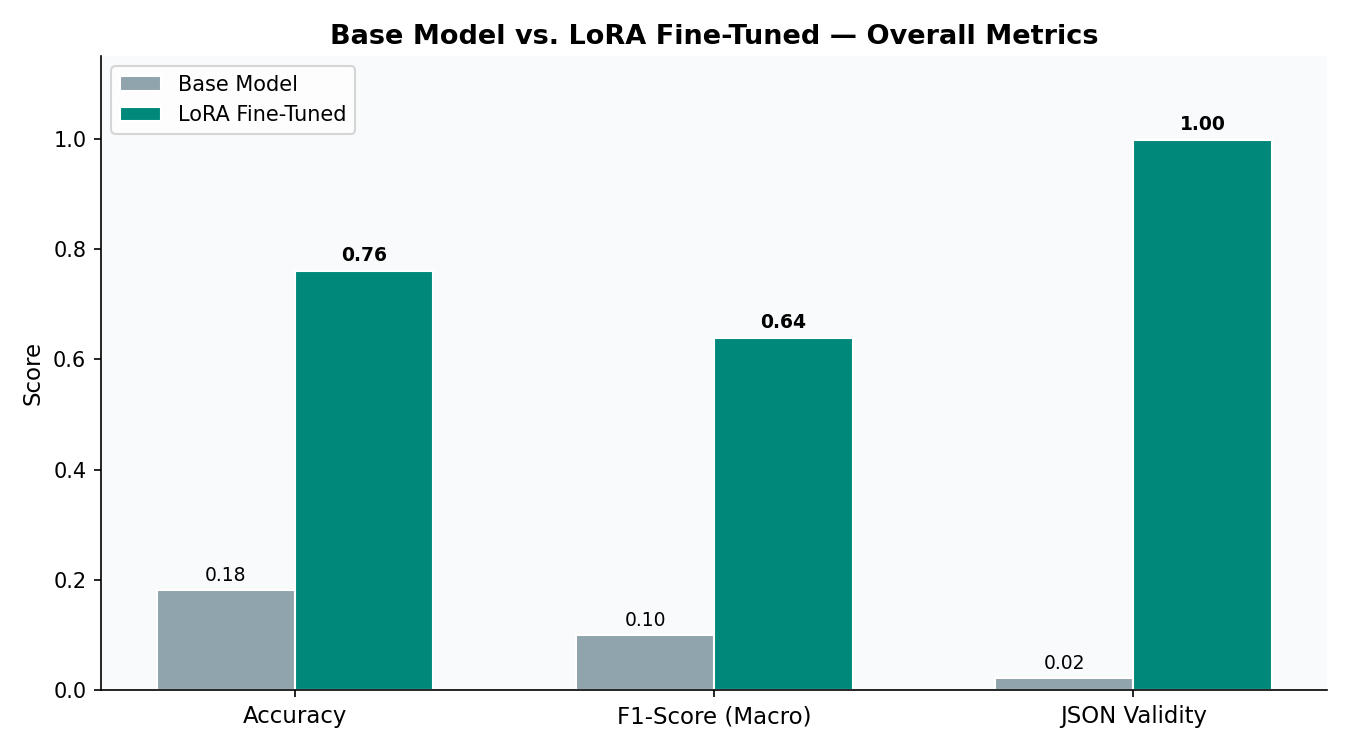


📊 Per-Class F1


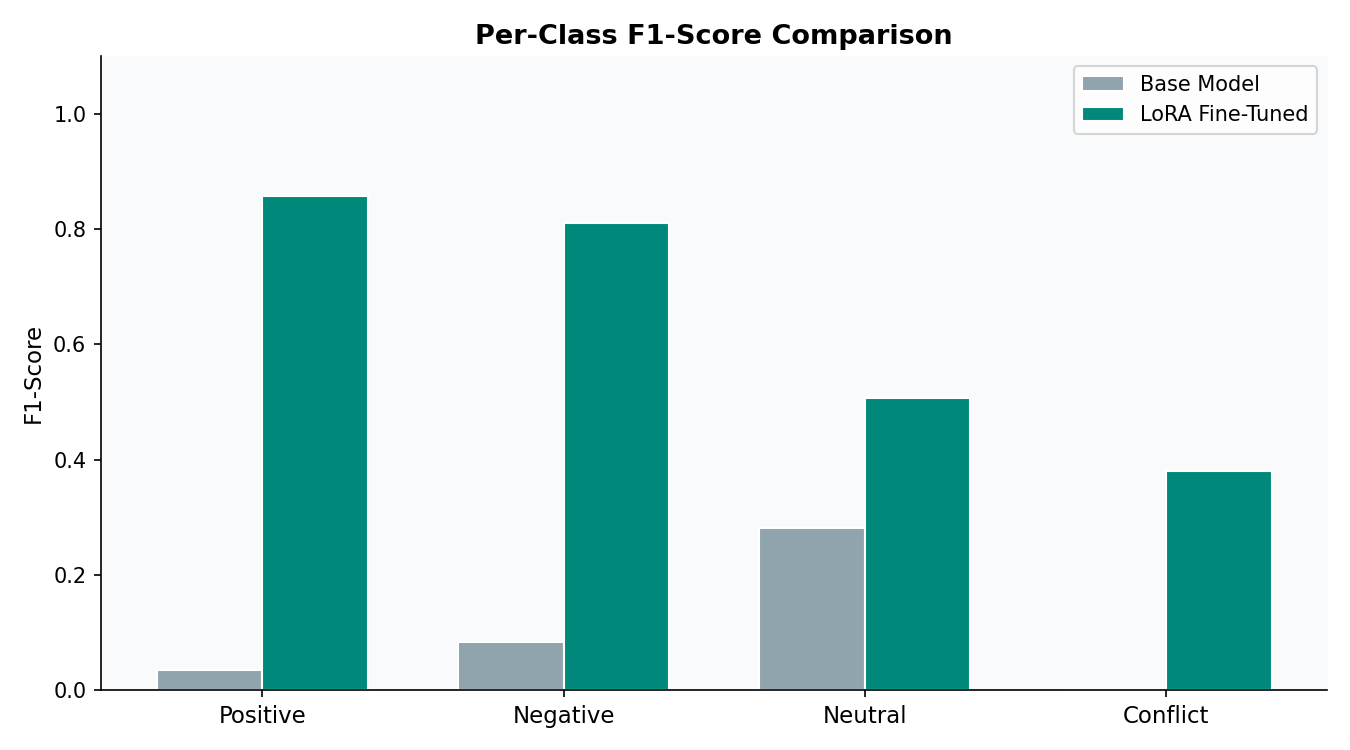


📊 Confusion Matrix — Base


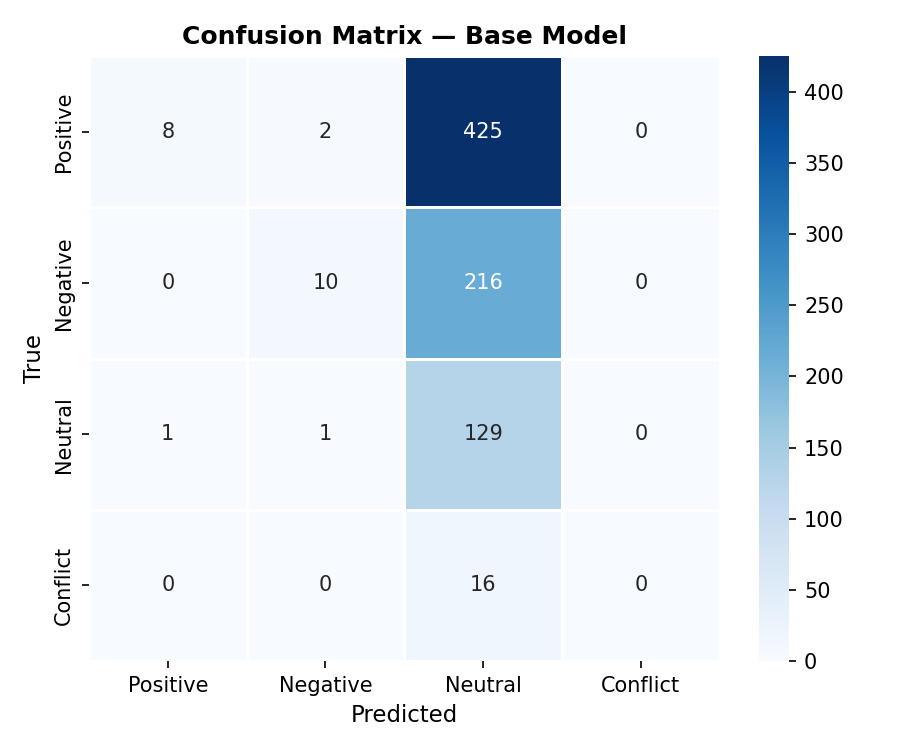


📊 Confusion Matrix — LoRA


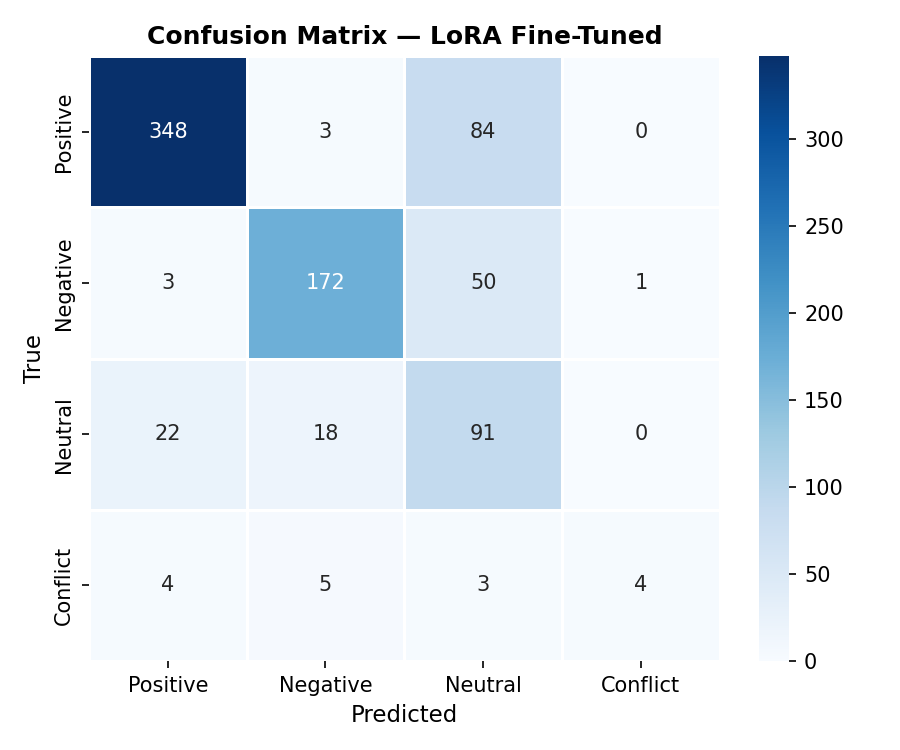

In [17]:
# ── Cell 7c: Display All Plots ───────────────────────────────────────────────

from IPython.display import Image, display
import os

plots = [
    ("outputs/evaluation/comparison_bar.png",        "Overall Comparison"),
    ("outputs/evaluation/per_class_f1.png",          "Per-Class F1"),
    ("outputs/evaluation/confusion_matrix_base.png", "Confusion Matrix — Base"),
    ("outputs/evaluation/confusion_matrix_lora.png", "Confusion Matrix — LoRA"),
]
for path, title in plots:
    if os.path.exists(path):
        print(f"\n📊 {title}")
        display(Image(path))
    else:
        print(f"⚠️  {title} not found — run Cell 7 first")

In [18]:
# ── Cell 8: Load Fine-Tuned Model for Inference ──────────────────────────────
# Loads base model in 4-bit float16 (T4-safe) and attaches LoRA adapter

import os, sys, torch, json, warnings
warnings.filterwarnings("ignore")

os.environ["USE_TF"]  = "0"
os.environ["USE_JAX"] = "0"

project_path = "/kaggle/working/opinion_mining_project"
os.chdir(project_path)
sys.path.insert(0, project_path)

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from config import model_cfg
from inference import predict, pretty_print

# Verify versions
import transformers, bitsandbytes, peft
print(f"transformers : {transformers.__version__}")
print(f"bitsandbytes : {bitsandbytes.__version__}")
print(f"GPU          : {torch.cuda.get_device_name(0)}")

# ── Tokenizer ─────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(
    model_cfg.model_name,
    trust_remote_code=True,
    use_fast=False,
)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id
print("\n✅ Tokenizer loaded")

# ── 4-bit NF4 config (float16 — T4 safe) ──────────────────────────────────────
bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# ── Base model ────────────────────────────────────────────────────────────────
print("\n⏳ Loading base model (~2–3 min)...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_cfg.model_name,
    quantization_config=bnb_cfg,
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True,
    low_cpu_mem_usage=True,
)
print("✅ Base model loaded")

# ── Attach adapter ────────────────────────────────────────────────────────────
# Use ADAPTER_PATH from Cell 6, or set manually here:
ADAPTER_PATH = "/kaggle/input/datasets/saifmamdouh11/opinion-mining-project"   # change if needed

# Try local first, then fall back to dataset
if os.path.exists("/kaggle/working/opinion_mining_project/final_adapter/adapter_config.json"):
    ADAPTER_PATH = "/kaggle/working/opinion_mining_project/final_adapter"

print(f"\n⏳ Attaching LoRA adapter from: {ADAPTER_PATH}")
ft_model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
ft_model.eval()
print("✅ Model ready!")

transformers : 4.46.3
bitsandbytes : 0.45.3
GPU          : Tesla T4

✅ Tokenizer loaded

⏳ Loading base model (~2–3 min)...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Base model loaded

⏳ Attaching LoRA adapter from: /kaggle/input/datasets/saifmamdouh11/opinion-mining-project
✅ Model ready!


In [19]:
# ── Cell 9: Inference Demo ───────────────────────────────────────────────────
# Run the fine-tuned model on test reviews

test_reviews = [
    "The battery life is outstanding but the screen is way too dim and the price is overpriced.",
    "Food was incredible — especially the pasta. But the service was painfully slow.",
    "Great keyboard and fast SSD, but the fan noise is unbearable and webcam is terrible.",
    "The camera's battery drains ridiculously fast.",
    "I loved the cozy atmosphere and the friendly staff, though the pasta was a bit too salty.",
    "The customer service team fixed my software issue in under five minutes.",
]

for review in test_reviews:
    result = predict(ft_model, tokenizer, review)
    pretty_print(result)
    print()
    print("JSON Output:")
    print(json.dumps({
        "aspects":           result["aspects"],
        "overall_sentiment": result["overall_sentiment"],
    }, indent=2))
    print()


──────────────────────────────────────────────────────────────
📝 Review:
   The battery life is outstanding but the screen is way too dim and the price is overpriced.

🔍 Extracted Aspects:
   ✅  battery life                     [positive]
   ❌  screen                           [negative]
   ❌  price                            [negative]

🏷️  Overall Sentiment : MIXED
📦 JSON Valid        : Yes

📤 Raw output:
   {"aspects": [{"term": "battery life", "sentiment": "positive"}, {"term": "screen", "sentiment": "negative"}, {"term": "price", "sentiment": "negative"}]}
──────────────────────────────────────────────────────────────

JSON Output:
{
  "aspects": [
    {
      "term": "battery life",
      "sentiment": "positive"
    },
    {
      "term": "screen",
      "sentiment": "negative"
    },
    {
      "term": "price",
      "sentiment": "negative"
    }
  ],
  "overall_sentiment": "mixed"
}


──────────────────────────────────────────────────────────────
📝 Review:
   Food was incredi

In [20]:
# ── Cell 10: Styled Results Table ────────────────────────────────────────────
import warnings, pandas as pd
warnings.filterwarnings("ignore")

SENTIMENT_EMOJI = {
    "positive": "✅", "negative": "❌",
    "neutral":  "⬜", "conflict": "⚠️", "mixed": "🔀",
}

print("⏳ Processing reviews...")
rows = []
for review in test_reviews:
    result   = predict(ft_model, tokenizer, review)
    aspects  = result.get("aspects", [])
    formatted = "\n".join([
        f"• {a['term']}  {SENTIMENT_EMOJI.get(a['sentiment'],'')} {a['sentiment'].upper()}"
        for a in aspects
    ]) if aspects else "⚠️ None"
    overall  = result.get("overall_sentiment", "unknown").upper()
    rows.append({
        "Review Text":       review,
        "Extracted Aspects": formatted,
        "Overall":           f"{SENTIMENT_EMOJI.get(overall.lower(),'')} {overall}",
    })

df = pd.DataFrame(rows)

def row_color(row):
    sentiment = row["Overall"]
    if   "POSITIVE" in sentiment: bg = "#E8F5E9"  # green tint
    elif "NEGATIVE" in sentiment: bg = "#FFEBEE"  # red tint
    elif "MIXED"    in sentiment: bg = "#E3F2FD"  # blue tint
    else:                         bg = "#F5F5F5"  # grey
    return [f"background-color: {bg}; color: #1A1A1A; text-align: left; "
            f"white-space: pre-wrap; padding: 10px 14px; font-size: 13px;"] * len(row)

styled = (
    df.style
      .apply(row_color, axis=1)
      .set_table_styles([
          {"selector": "th", "props": [
              ("background-color", "#1A237E"),
              ("color",            "white"),
              ("font-size",        "14px"),
              ("text-align",       "left"),
              ("padding",          "12px 14px"),
          ]},
      ])
      .hide(axis="index")
)

print("✅ Done!\n")
display(styled)

⏳ Processing reviews...
✅ Done!



Review Text,Extracted Aspects,Overall
The battery life is outstanding but the screen is way too dim and the price is overpriced.,• battery life ✅ POSITIVE • screen ❌ NEGATIVE • price ❌ NEGATIVE,🔀 MIXED
Food was incredible — especially the pasta. But the service was painfully slow.,• Food ✅ POSITIVE • pasta ✅ POSITIVE • service ❌ NEGATIVE,🔀 MIXED
"Great keyboard and fast SSD, but the fan noise is unbearable and webcam is terrible.",• keyboard ✅ POSITIVE • SSD ✅ POSITIVE • fan noise ❌ NEGATIVE • webcam ❌ NEGATIVE,🔀 MIXED
The camera's battery drains ridiculously fast.,• camera ❌ NEGATIVE • battery ❌ NEGATIVE,❌ NEGATIVE
"I loved the cozy atmosphere and the friendly staff, though the pasta was a bit too salty.",• atmosphere ✅ POSITIVE • staff ✅ POSITIVE • pasta ❌ NEGATIVE,🔀 MIXED
The customer service team fixed my software issue in under five minutes.,• customer service team ✅ POSITIVE • software ⬜ NEUTRAL,✅ POSITIVE


In [21]:
%%writefile /kaggle/working/opinion_mining_project/app.py
"""
app.py — Gradio GUI for Opinion Mining (Kaggle T4 - Fixed Version)
"""
import json, os, re, sys, tempfile, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import gradio as gr
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

PROJECT_DIR = Path(__file__).resolve().parent
sys.path.insert(0, str(PROJECT_DIR))
from config import model_cfg, data_cfg, inference_cfg
from data.prepare_dataset import build_prompt

# ── Config ────────────────────────────────────────────────────────────────────
ADAPTER_CANDIDATES = [
    str(PROJECT_DIR / "final_adapter"),
    "/kaggle/working/opinion_mining_project/final_adapter",
    "/kaggle/input/datasets/saifmamdouh11/opinion-mining-project",
]
SENTIMENT_EMOJI = {
    "positive": "✅", "negative": "❌",
    "neutral": "⬜", "conflict": "⚠️",
}
VALID_SENTIMENTS = {"positive", "negative", "neutral", "conflict"}
EXAMPLES = [
    "The laptop's battery life is outstanding and the keyboard feels great, but the display has poor brightness.",
    "Food was absolutely delicious especially the pasta, but the service was painfully slow.",
    "Solid build quality and blazing fast SSD, but the fan noise is distracting.",
    "The camera keeps crashing, the battery drains ridiculously fast, and customer support was unhelpful.",
    "I loved the cozy atmosphere and the friendly staff, though the pasta was a bit too salty.",
]

_base_model = _ft_model = _tokenizer = None
_adapter_loaded = False


# ── Model loading ─────────────────────────────────────────────────────────────
def _bnb():
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

def load_models():
    global _base_model, _ft_model, _tokenizer, _adapter_loaded
    os.environ["TOKENIZERS_PARALLELISM"] = "false"

    print("[LOAD] Tokenizer...")
    _tokenizer = AutoTokenizer.from_pretrained(
        model_cfg.model_name, trust_remote_code=True, use_fast=False
    )
    _tokenizer.pad_token    = _tokenizer.eos_token
    _tokenizer.pad_token_id = _tokenizer.eos_token_id
    print("✅ Tokenizer ready")

    print("[LOAD] Base model (4-bit float16)...")
    _base_model = AutoModelForCausalLM.from_pretrained(
        model_cfg.model_name,
        quantization_config=_bnb(),
        device_map="auto",
        torch_dtype=torch.float16,
        trust_remote_code=True,
        low_cpu_mem_usage=True,
    )
    _base_model.eval()
    print("✅ Base model ready")

    # Find adapter
    adapter_path = None
    for c in ADAPTER_CANDIDATES:
        check = os.path.join(c, "adapter_config.json")
        if os.path.exists(check):
            adapter_path = c
            print(f"✅ Adapter found: {adapter_path}")
            break

    if adapter_path:
        _ft_model = PeftModel.from_pretrained(_base_model, adapter_path)
        _ft_model.eval()
        _adapter_loaded = True
        print("✅ Fine-tuned model ready")
    else:
        print("⚠️  No adapter found — using base model for both")
        _ft_model = _base_model
        _adapter_loaded = False


# ── Inference ─────────────────────────────────────────────────────────────────
def _generate(model, prompt: str) -> str:
    inputs = _tokenizer(
        prompt, return_tensors="pt",
        truncation=True, max_length=data_cfg.max_seq_length
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
            temperature=1.0,
            repetition_penalty=1.1,
            pad_token_id=_tokenizer.eos_token_id,
        )
    new_tokens = out[0][inputs["input_ids"].shape[1]:]
    return _tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


def _parse_aspects(raw: str):
    """
    Parse aspects from model output.
    Returns (aspects_list, json_valid, status_msg)
    Handles ALL formats the model might output.
    """
    def _extract_aspects_from_obj(obj):
        """Try to get aspects from a parsed JSON object."""
        if not isinstance(obj, dict):
            return None

        # Format 1: {"aspects": [{"term": ..., "sentiment": ...}]}
        if "aspects" in obj and isinstance(obj["aspects"], list):
            valid = []
            for a in obj["aspects"]:
                if not isinstance(a, dict): continue
                term = str(a.get("term", "")).strip()
                sent = str(a.get("sentiment", a.get("polarity", ""))).strip().lower()
                if term and sent in VALID_SENTIMENTS:
                    valid.append({"term": term, "sentiment": sent})
            return valid  # may be empty list — that's valid

        # Format 2: flat key-value {"battery life": "positive", "screen": "negative"}
        # (where all values are sentiment labels)
        flat = []
        for k, v in obj.items():
            if k in ("overall_sentiment", "overall", "sentiment"): continue
            v_lower = str(v).strip().lower()
            if v_lower in VALID_SENTIMENTS and len(str(k).strip()) > 0:
                flat.append({"term": str(k).strip(), "sentiment": v_lower})
        if flat:
            return flat

        # Format 3: {"term": "battery", "sentiment": "positive"} — single aspect
        term = str(obj.get("term", obj.get("aspect", ""))).strip()
        sent = str(obj.get("sentiment", obj.get("polarity", ""))).strip().lower()
        if term and sent in VALID_SENTIMENTS:
            return [{"term": term, "sentiment": sent}]

        return None

    def _try_parse(text):
        try:
            obj = json.loads(text)
            result = _extract_aspects_from_obj(obj)
            if result is not None:
                return result, True
        except Exception:
            pass
        return None, False

    # 1. Try direct parse
    aspects, valid = _try_parse(raw)
    if aspects is not None:
        msg = "✅ Valid JSON" if aspects else "ℹ️ No aspects found in this review"
        return aspects, valid, msg

    # 2. Try extracting JSON block from text
    for match in re.finditer(r'\{[^{}]*\}|\{.*?\}', raw, re.DOTALL):
        aspects, valid = _try_parse(match.group())
        if aspects is not None:
            msg = "✅ Valid JSON" if aspects else "ℹ️ No aspects found in this review"
            return aspects, valid, msg

    # 3. Try to find JSON array directly
    arr_match = re.search(r'\[.*?\]', raw, re.DOTALL)
    if arr_match:
        try:
            arr = json.loads(arr_match.group())
            if isinstance(arr, list):
                valid_items = []
                for a in arr:
                    if isinstance(a, dict):
                        term = str(a.get("term","")).strip()
                        sent = str(a.get("sentiment","")).strip().lower()
                        if term and sent in VALID_SENTIMENTS:
                            valid_items.append({"term": term, "sentiment": sent})
                if valid_items:
                    return valid_items, True, "✅ Valid JSON"
        except Exception:
            pass

    # 4. Nothing worked
    return [], False, f"⚠️ Could not parse JSON\n\n**Raw output:**\n```\n{raw[:400]}\n```"


def _overall(aspects):
    if not aspects: return "neutral"
    pos = sum(1 for a in aspects if a["sentiment"] == "positive")
    neg = sum(1 for a in aspects if a["sentiment"] == "negative")
    if pos > 0 and neg > 0: return "mixed"
    if pos > neg: return "positive"
    if neg > pos: return "negative"
    return "neutral"


# ── Tab 1: Single Review ──────────────────────────────────────────────────────
def analyze_single(review: str):
    if not review.strip():
        return "⚠️ Please enter a review.", "{}", "—"

    raw = _generate(_ft_model, build_prompt(review))
    aspects, json_valid, status = _parse_aspects(raw)
    overall = _overall(aspects)

    if aspects:
        lines = ["| Aspect | Sentiment |", "|--------|-----------|"]
        for a in aspects:
            emoji = SENTIMENT_EMOJI.get(a["sentiment"], "•")
            lines.append(f"| **{a['term']}** | {emoji} {a['sentiment']} |")
        aspects_md = "\n".join(lines)
    else:
        aspects_md = status

    json_out = json.dumps(
        {"aspects": aspects, "overall_sentiment": overall},
        indent=2, ensure_ascii=False
    )
    overall_md = f"**{overall.upper()}** {SENTIMENT_EMOJI.get(overall, '')}"
    return aspects_md, json_out, overall_md


# ── Tab 2: Compare ────────────────────────────────────────────────────────────
def compare_models(review: str):
    if not review.strip():
        return "⚠️ Please enter a review.", "⚠️ Please enter a review."

    prompt = build_prompt(review)

    def _format_result(model, label):
        raw = _generate(model, prompt)
        aspects, json_valid, status = _parse_aspects(raw)
        overall  = _overall(aspects)
        valid_icon = "✅ Yes" if json_valid else "❌ No"

        md = f"**JSON Valid:** {valid_icon}\n\n"
        if aspects:
            md += "| Aspect | Sentiment |\n|--------|----------|\n"
            for a in aspects:
                emoji = SENTIMENT_EMOJI.get(a["sentiment"], "•")
                md += f"| **{a['term']}** | {emoji} {a['sentiment']} |\n"
            md += f"\n**Overall:** {overall.upper()} {SENTIMENT_EMOJI.get(overall,'')}"
            md += f"\n\n```json\n{json.dumps({'aspects': aspects, 'overall_sentiment': overall}, indent=2)}\n```"
        elif json_valid:
            md += "ℹ️ JSON valid but no aspects found."
        else:
            md += status
        return md

    base_md = _format_result(_base_model, "Base")
    ft_md   = _format_result(_ft_model,   "LoRA")
    return base_md, ft_md


# ── Tab 3: Batch ─────────────────────────────────────────────────────────────
def process_batch(file_obj, progress=gr.Progress()):
    if file_obj is None:
        return None, "⚠️ No file uploaded."
    lines   = Path(file_obj.name).read_text(encoding="utf-8").splitlines()
    reviews = [l.strip() for l in lines if l.strip()]
    if not reviews:
        return None, "⚠️ File is empty."

    results = []
    for review in progress.tqdm(reviews, desc="Processing"):
        raw     = _generate(_ft_model, build_prompt(review))
        aspects, json_valid, _ = _parse_aspects(raw)
        overall = _overall(aspects)
        results.append({
            "review": review, "aspects": aspects,
            "overall_sentiment": overall,
            "json_valid": json_valid,
        })

    out = tempfile.NamedTemporaryFile(
        mode="w", suffix=".jsonl", delete=False, encoding="utf-8"
    )
    for r in results:
        out.write(json.dumps(r, ensure_ascii=False) + "\n")
    out.close()

    n_valid = sum(1 for r in results if r["json_valid"])
    counts  = {}
    for r in results:
        counts[r["overall_sentiment"]] = counts.get(r["overall_sentiment"], 0) + 1

    summary = (
        f"### ✅ Done — {len(results)} reviews processed\n\n"
        f"| Metric | Value |\n|--------|-------|\n"
        f"| Total reviews | {len(results)} |\n"
        f"| JSON valid | {n_valid} ({100*n_valid//len(results)}%) |\n"
    )
    for s, c in sorted(counts.items()):
        summary += f"| {s.capitalize()} | {c} |\n"
    return out.name, summary


# ── Build UI ──────────────────────────────────────────────────────────────────
def build_ui():
    adapter_note = "✅ LoRA adapter loaded" if _adapter_loaded else "⚠️ No adapter — base model only"

    with gr.Blocks(
        title="Opinion Mining",
        theme=gr.themes.Soft(
            primary_hue="teal", neutral_hue="slate",
            font=gr.themes.GoogleFont("Inter"),
        ),
    ) as demo:
        gr.Markdown(f"""
# 🔍 Opinion Mining — Aspect-Based Sentiment Analysis
**Fine-tuned LLaMA-3.2-3B · LoRA (QLoRA) · Kaggle T4 GPU** &nbsp;|&nbsp; {adapter_note}

| Accuracy **76%** | F1-Score **64%** | JSON Validity **99.8%** | Trainable params **0.13%**
""")
        with gr.Tabs():

            with gr.Tab("📝 Single Review"):
                gr.Markdown("Enter a customer review to extract aspects and sentiments.")
                with gr.Row():
                    with gr.Column(scale=3):
                        inp1 = gr.Textbox(
                            label="Review text", lines=4,
                            placeholder="e.g. The battery life is great but the screen is too dim…"
                        )
                        gr.Examples(examples=EXAMPLES, inputs=inp1, label="Example reviews")
                        btn1 = gr.Button("Analyze", variant="primary")
                    with gr.Column(scale=2):
                        overall1 = gr.Markdown(label="Overall Sentiment")
                        aspects1 = gr.Markdown(label="Extracted Aspects")
                json1 = gr.Code(label="JSON Output", language="json", lines=10)
                btn1.click(analyze_single, inputs=inp1,
                           outputs=[aspects1, json1, overall1])

            with gr.Tab("⚖️ Base vs Fine-Tuned"):
                gr.Markdown("Compare zero-shot base model vs LoRA fine-tuned on the same review.")
                inp2 = gr.Textbox(label="Review text", lines=3, value=EXAMPLES[0])
                btn2 = gr.Button("Compare both models", variant="primary")
                with gr.Row():
                    with gr.Column():
                        gr.Markdown("### ✗ Base Model (zero-shot)")
                        base_out = gr.Markdown()
                    with gr.Column():
                        gr.Markdown("### ✓ LoRA Fine-Tuned")
                        ft_out = gr.Markdown()
                btn2.click(compare_models, inputs=inp2, outputs=[base_out, ft_out])

            with gr.Tab("📦 Batch Mode"):
                gr.Markdown("Upload a `.txt` file — one review per line.")
                file_in  = gr.File(label="Upload (.txt)", file_types=[".txt"])
                btn3     = gr.Button("Process all reviews", variant="primary")
                with gr.Row():
                    summary3 = gr.Markdown()
                    file_out = gr.File(label="Download predictions (.jsonl)")
                btn3.click(process_batch, inputs=file_in,
                           outputs=[file_out, summary3])

        gr.Markdown(
            "*Model: `meta-llama/Llama-3.2-3B-Instruct` "
            "fine-tuned with LoRA on SemEval-2014 Task 4*"
        )
    return demo


# ── Main ─────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    import argparse
    p = argparse.ArgumentParser()
    p.add_argument("--share",    action="store_true", default=True)
    p.add_argument("--no-share", action="store_true")
    p.add_argument("--port",     type=int, default=7860)
    args = p.parse_args()

    load_models()
    build_ui().launch(
        share=not args.no_share,
        server_port=args.port,
        server_name="0.0.0.0",
        show_error=True,
    )

Writing /kaggle/working/opinion_mining_project/app.py


In [22]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.chdir("/kaggle/working/opinion_mining_project")
!python app.py --share

[LOAD] Tokenizer...
✅ Tokenizer ready
[LOAD] Base model (4-bit float16)...
Loading checkpoint shards: 100%|██████████████████| 2/2 [00:06<00:00,  3.33s/it]
✅ Base model ready
✅ Adapter found: /kaggle/input/datasets/saifmamdouh11/opinion-mining-project
✅ Fine-tuned model ready
* Running on local URL:  http://0.0.0.0:7860
* Running on public URL: https://0626bc881b8e6c0299.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
^C
Keyboard interruption in main thread... closing server.
Killing tunnel 0.0.0.0:7860 <> https://0626bc881b8e6c0299.gradio.live
